In [2]:
import pandas as pd
import re
from Bio import SeqIO
from Bio.Seq import Seq

In [3]:
ref_record = SeqIO.read("/Users/reem/wuhan_reference.fasta", "fasta")
ref_seq = str(ref_record.seq)
len(ref_seq)

29903

In [15]:
# ── SARS-CoV-2 gene coordinates (Wuhan NC_045512.2) ──────
# from nextclade reference annotation gff3 file, which is based on NC_045512.2
genes = {
    "ORF1a"  : (266,   13483),
    "ORF1b" :  (13468, 21555),      #Frameshift overlap with ORF1a, so start is 15 bases before ORF1a end
    "S"      : (21563, 25384),
    "ORF3a"  : (25393, 26220),
    "E"      : (26245, 26472),
    "M"      : (26523, 27191),
    "ORF6"   : (27202, 27387),
    "ORF7a"  : (27394, 27759),
    "ORF7b"  : (27756, 27887),
    "ORF8"   : (27894, 28259),
    "N"      : (28274, 29533),
    "ORF10"  : (29558, 29674)
}

In [16]:
def get_context(nt_pos):
    """Trinucleotide context (1-based position)"""
    if nt_pos < 2 or nt_pos > len(ref_seq) - 1:
        return "N/A"
    return ref_seq[nt_pos - 2 : nt_pos + 1]  # 0-based slicing


In [17]:
# Use ORF1ab for positions > 13483, ORF1a for positions <= 13483
# to avoid double-counting the overlapping region
def get_gene(nt_pos):
    """Return the single most specific gene for a nucleotide position."""
    for gene, (start, end) in genes.items():
        if gene == "ORF1a" and nt_pos > 13467:
            continue
        if gene == "ORF1b" and nt_pos < 13468:
            continue  # prefer ORF1a in overlap region
        if start <= nt_pos <= end:
            return gene, start, end
    return None, None, None

In [18]:
codon_table = {}

def translate_codon(codon):
    """Translate a codon to amino acid, with caching."""
    if codon in codon_table:
        return codon_table[codon]
    aa = str(Seq(codon).translate())   #from Bio.Seq import Seq
    codon_table[codon] = aa
    return aa


In [19]:
def get_codon_info(nt_pos, alt_nt):
    """Given a nucleotide position and alt allele, return codon-level info."""
    gene, gene_start, gene_end = get_gene(nt_pos)
    if gene is None:
        return None
    # Position within CDS (1-based)
    cds_pos    = nt_pos - gene_start + 1
    codon_num  = (cds_pos - 1) // 3        # 0-based codon index
    codon_pos  = (cds_pos - 1) %  3        # 0-based position within codon
    aa_index   = codon_num + 1             # 1-based amino acid index

    # Codon start in genome (0-based for string slicing)
    codon_start_0 = gene_start - 1 + codon_num * 3                      # 0-based codon start, add 1 to convert to genomic coordinates
    ref_codon     = ref_seq[codon_start_0 : codon_start_0 + 3]

    # Build mutant codon dict
    mut_codon_list        = list(ref_codon)
    mut_codon_list[codon_pos] = alt_nt
    mut_codon             = "".join(mut_codon_list)

    ref_aa = translate_codon(ref_codon)
    mut_aa = translate_codon(mut_codon)

    return {
        "gene"         : gene,
        "gene_start"   : gene_start,
        "nt_index"     : nt_pos,
        "cds_pos"      : cds_pos,
        "aa_index"     : aa_index,
        "ref_codon"    : ref_codon,
        "mut_codon"    : mut_codon,
        "ref_aa"       : ref_aa,
        "mut_aa"       : mut_aa,
        "is_synonymous": ref_aa == mut_aa
    }


In [12]:
get_codon_info(21563, "A")

{'gene': 'S',
 'gene_start': 21563,
 'nt_index': 21563,
 'cds_pos': 1,
 'aa_index': 1,
 'ref_codon': 'ATG',
 'mut_codon': 'ATG',
 'ref_aa': 'M',
 'mut_aa': 'M',
 'is_synonymous': True}

In [14]:
df = pd.read_csv("/Users/reem/merged_bte_final.tsv", sep = "\t")
non_mov = df[~((df["LLR"]>3) & (df["sum_contexts"]>2))]
len(non_mov)



8942695

In [ ]:
import ast

# Create a table of coding mutations for both MOV and non-MOV nodes, with codon and amino acid info
mov = df[(df["LLR"]>3) & (df["sum_contexts"]>2)]
# non_mov = df[~(df["LLR"]>3) & (df["sum_contexts"]>2)]

# ── Load UShER output ────────────────────────────────────────────────────

print(f"Total MOV nodes: {len(mov)}")
print(f"Columns: {list(mov.columns)}")
print(mov[["node_id", "mutations", "num_mutations"]].head(3))

# ── Parse mutations column ────────────────────────────────────────────────────
# Format: 'C1758T', 'C7600T', ... (looks like a Python list with quoted strings)

def parse_mutations(mut_str):
    """Parse BTE mutations string into a list of mutation strings."""
    if pd.isna(mut_str) or mut_str == "[]":
        return []
    try:
        # Remove surrounding brackets if present and split by comma
        mut_str = mut_str.strip()
        # Use ast.literal_eval if it looks like a proper Python list
        if mut_str.startswith("["):
            return [m.strip() for m in ast.literal_eval(mut_str)]
        else:
            # Handle format: 'C1758T', 'C7600T', ...
            return [m.strip().strip("'") for m in mut_str.split(",")]
    except Exception:
        # Fallback: regex extract all mutation patterns
        return re.findall(r"[ACGT]\d+[ACGT]", mut_str)

# ── Process all nodes ─────────────────────────────────────────────────────────
rows = []
skipped = 0

for _, node_row in mov.iterrows():
    muts = parse_mutations(node_row["mutations"])
    
    for mut in muts:
        mut = mut.strip()
        m = re.match(r"^([ACGT])(\d+)([ACGT])$", mut)
        if not m:
            skipped += 1
            continue
        
        ref_nt, pos, alt_nt = m.group(1), int(m.group(2)), m.group(3)
        info = get_codon_info(pos, alt_nt)
        
        if info is None:
            continue  # intergenic or UTR — skip
        
        rows.append({
            "node_id"      : node_row["node_id"],
            "nt_mut"       : mut,
            "ref_nt"       : ref_nt,
            "alt_nt"       : alt_nt,
            "num_mutations": node_row["num_mutations"],
            "LLR"          : node_row["LLR"],
            "sum_contexts" : node_row["sum_contexts"],
            "cluster_size" : node_row["num_descendants"],
            "country"      : node_row.get("country", None),
            "year"          : node_row.get("date", None),
            **info
        })


data_muts = pd.DataFrame(rows)

print(f"\nSkipped non-standard mutations : {skipped}")
print(f"Total coding mutation rows     : {len(data_muts)}")
print(f"Unique nodes                   : {data_muts['node_id'].nunique()}")

# ── Mutation type ─────────────────────────────────────────────────────────────
data_muts["mut_type"] = data_muts.apply(
    lambda r: "Synonymous"           if r["is_synonymous"]
         else "STOP"                 if r["mut_aa"] == "*"
         else "Non-synonymous",
    axis=1
)

mov_mut_counts = data_muts["mut_type"].value_counts()
#data_muts.to_csv("/Users/reem/mov_coding_mutations.csv", index=False)

In [27]:
mov = pd.read_csv("/Users/reem/mov_coding_mutations.tsv", sep="\t")
non_mov = pd.read_csv("/Users/reem/non_mov_coding_mutations.tsv", sep="\t")

In [29]:
# Percentage of Non-synonymous mutations in MOV nodes
non_syn_count = len(mov[mov["mut_type"] == "Non-synonymous"])
total_count = len(mov)
non_syn_percentage = (non_syn_count / total_count) * 100 if total_count > 0 else 0
print(f"Percentage of all Non-synonymous mutations in MOV nodes: {non_syn_percentage:.2f}%")

Percentage of all Non-synonymous mutations in MOV nodes: 57.00%


In [36]:
# Get Null Distribution of non-synonymous fraction for same transition types in MOV and non-MOV nodes

from Bio import SeqIO
from Bio.Data import CodonTable

# Standard codon table
codon_table = CodonTable.unambiguous_dna_by_name["Standard"].forward_table
stop_codons = CodonTable.unambiguous_dna_by_name["Standard"].stop_codons


syn = 0
nonsyn = 0

for gene, (start, end) in genes.items():
    cds = ref_seq[start:end]
    cds = cds[:len(cds) - (len(cds) % 3)]
    for i in range(len(cds)):          # iterate ALL positions
        codon = cds[i - (i % 3): i - (i % 3) + 3]
        if len(codon) != 3 or 'N' in codon:
            continue
        pos_in_codon = i % 3
        ref_base = cds[i]
       
        
        # Only G→A and C→T
        # Replace the G→A C→T filter with all four MOV transitions
        if ref_base == 'G':
            alt_base = 'A'
        elif ref_base == 'C':
            alt_base = 'T'
        elif ref_base == 'A':
            alt_base = 'G'
        elif ref_base == 'T':
            alt_base = 'C'
        else:
            continue
            
        mut_codon = list(codon)
        mut_codon[pos_in_codon] = alt_base
        mut_codon = ''.join(mut_codon)
        
       
        ref_aa = codon_table.get(codon) or ('*' if codon in stop_codons else None)
        mut_aa = codon_table.get(mut_codon) or ('*' if mut_codon in stop_codons else None)
        
        if ref_aa is None or mut_aa is None:
            continue
            
        if ref_aa == mut_aa:
            syn += 1
        else:
            nonsyn += 1

total = syn + nonsyn
print(f"Synonymous: {syn} ({syn/total:.3f})")
print(f"Non-synonymous: {nonsyn} ({nonsyn/total:.3f})")
print(f"Total possible G>A + C>T + A>G + T>C mutations in coding genome: {total}")

Synonymous: 10694 (0.366)
Non-synonymous: 18550 (0.634)
Total possible G>A + C>T + A>G + T>C mutations in coding genome: 29244


In [37]:
# Filter to MOV-relevant transition types only
mov_transitions = mov[
    ((mov['ref_nt']=='G') & (mov['alt_nt']=='A')) |
    ((mov['ref_nt']=='C') & (mov['alt_nt']=='T')) |
    ((mov['ref_nt']=='A') & (mov['alt_nt']=='G')) |
    ((mov['ref_nt']=='T') & (mov['alt_nt']=='C'))
]
non_mov_transitions = non_mov[
    ((non_mov['ref_nt']=='G') & (non_mov['alt_nt']=='A')) |
    ((non_mov['ref_nt']=='C') & (non_mov['alt_nt']=='T')) |
    ((non_mov['ref_nt']=='A') & (non_mov['alt_nt']=='G')) |
    ((non_mov['ref_nt']=='T') & (non_mov['alt_nt']=='C'))
]

# Observed non-syn fraction in MOV nodes (G>A and C>T only)
mov_nonsyn = (~mov_transitions['is_synonymous']).mean()

# Null expectation: non-syn fraction of same transition types in non-MOV nodes
null_nonsyn = (~non_mov_transitions['is_synonymous']).mean()

# All-mutation observed for comparison
mov_all_nonsyn = (~mov['is_synonymous']).mean()
non_mov_all_nonsyn = (~non_mov['is_synonymous']).mean()

print(f"MOV G>A+C>T+A>G+T>C non-syn fraction: {mov_nonsyn:.3f}")
print(f"Non-MOV G>A+C>T+A>G+T>C non-syn fraction (null): {null_nonsyn:.3f}")
print(f"MOV all mutations non-syn: {mov_all_nonsyn:.3f}")
print(f"Non-MOV all mutations non-syn: {non_mov_all_nonsyn:.3f}")

MOV G>A+C>T+A>G+T>C non-syn fraction: 0.571
Non-MOV G>A+C>T+A>G+T>C non-syn fraction (null): 0.507
MOV all mutations non-syn: 0.573
Non-MOV all mutations non-syn: 0.572


In [ ]:
# ── 4. Syn vs non-syn proportions (purifying selection signal) ─────────────── dN/dS
for label, g in [("MOV", mov), ("non-MOV", non_mov)]:
    total = len(g)
    n_syn = (g["mut_type"] == "Synonymous").sum()
    n_non = (g["mut_type"] == "Non-synonymous").sum()
    pct   = n_non / (n_syn + n_non) * 100 if (n_syn + n_non) > 0 else 0
    print(f"{label}: {n_non} non-syn / {n_syn} syn  ({pct:.1f}% non-syn)")

MOV: 12163 non-syn / 9110 syn  (57.2% non-syn)
non-MOV: 8035468 non-syn / 6678838 syn  (54.6% non-syn)


In [ ]:
print(f"MOV mutations per node: {len(mov)/mov['node_id'].nunique():.1f}")
print(f"non-MOV mutations per node: {len(non_mov)/non_mov['node_id'].nunique():.1f}")

MOV mutations per node: 21.3
non-MOV mutations per node: 1.7


In [ ]:
def get_recurrent(group_df, min_count=4):
    return (
        group_df[group_df["mut_type"] == "Non-synonymous"]
        .groupby(["nt_index", "nt_mut", "gene", "ref_aa", "mut_aa", "aa_index"])
        .size()
        .reset_index(name="n")
        .query("n >= @min_count")
        .sort_values("n", ascending=False)
    )
mov_recurrent = get_recurrent(mov)
nonmov_recurrent = get_recurrent(non_mov)


MOV threshold:     4 nodes
non-MOV threshold: 4 nodes

MOV recurrent sites (≥4 nodes):     949
non-MOV recurrent sites (≥4 nodes): 24966


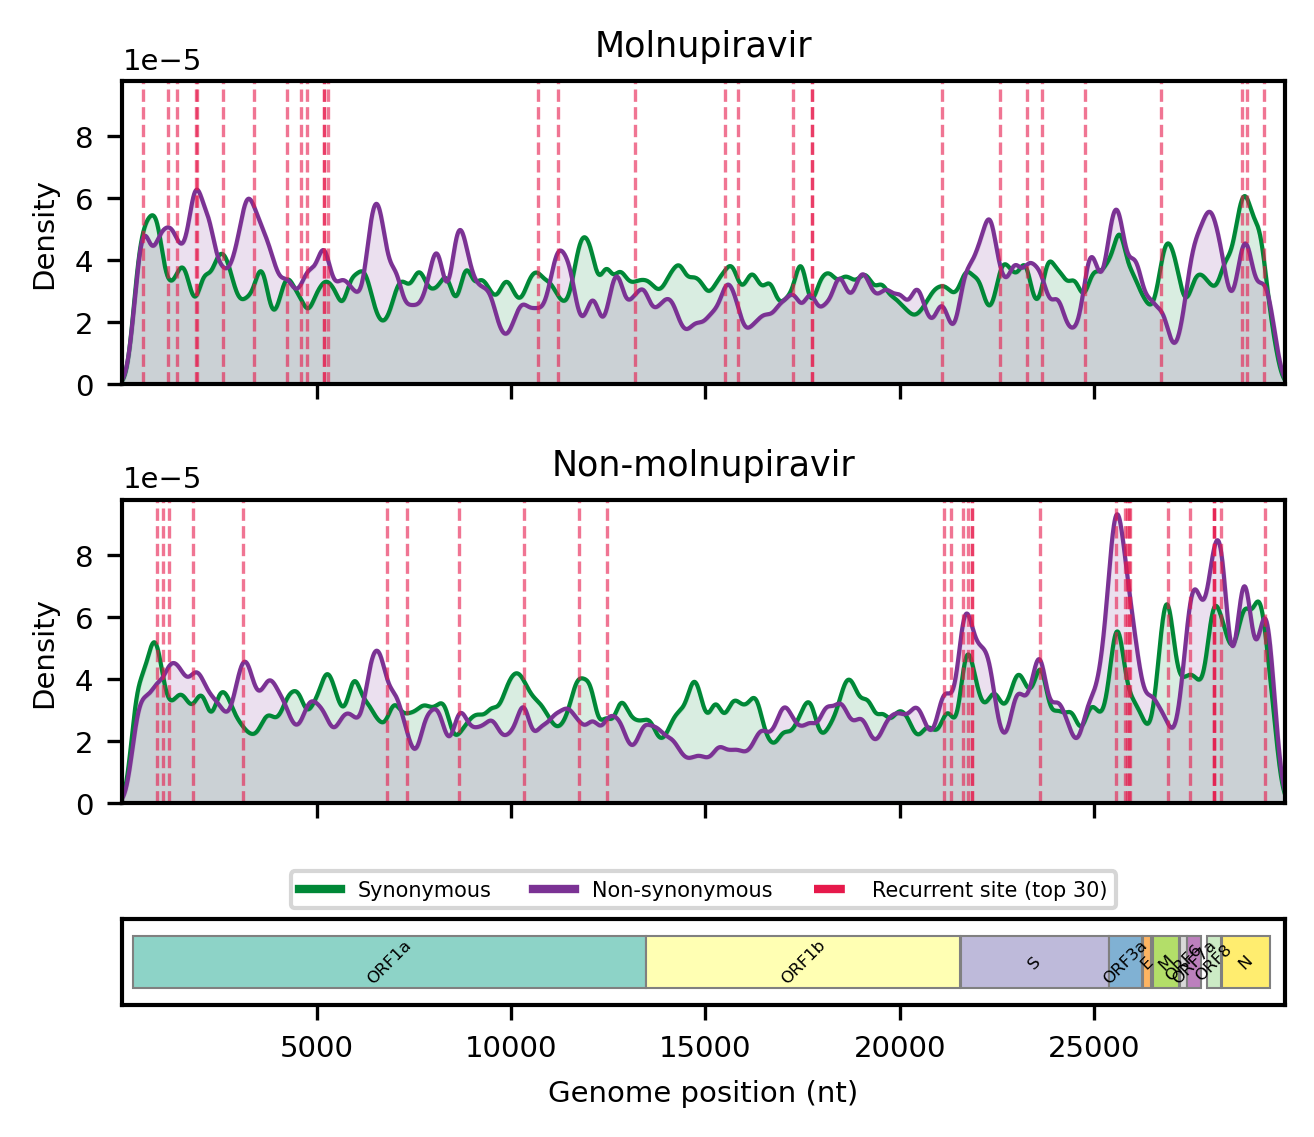


=== Top 15 recurrent non-syn sites: MOV ===
       nt_mut   gene ref_aa mut_aa  aa_index  n_nodes
1011   C4230T  ORF1a      T      I      1322       22
1189   C5178T  ORF1a      T      I      1638       18
1209   G5300A  ORF1a      A      T      1679       17
2549  C13197T  ORF1a      T      I      4311       17
1190   G5180A  ORF1a      D      N      1639       16
253    G1184A  ORF1a      A      T       307       16
4144  G23282A      S      D      N       574       16
3076  G17242A  ORF1b      A      T      1259       16
5225  C28791T      N      A      V       173       16
5343  C29370T      N      T      I       366       15
5269  G28925A      N      A      T       218       15
4362  G24770A      S      A      T      1070       15
3999  G22580A      S      E      K       340       15
426    G1886A  ORF1a      A      T       541       14
440    G1928A  ORF1a      A      T       555       14

=== Top 15 recurrent non-syn sites: non-MOV ===
        nt_mut   gene ref_aa mut_aa  aa_in

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import matplotlib as mpl
import matplotlib.gridspec as gridspec

# ── Define threshold ───────────────────────────────────────────────────────
mov_total_nodes    = mov["node_id"].nunique()
nonmov_total_nodes = non_mov["node_id"].nunique()

mov_threshold    = 4
nonmov_threshold = 4
 
print(f"MOV threshold:     {mov_threshold} nodes")
print(f"non-MOV threshold: {nonmov_threshold} nodes")

# ── Get recurrent sites per group ─────────────────────────────────────────────
def get_recurrent_1pct(group_df, threshold):
    """Find non-syn sites appearing in >= threshold nodes."""
    return (
        group_df[group_df["mut_type"] == "Non-synonymous"]
        .groupby(["nt_index", "nt_mut", "gene", "ref_aa", "mut_aa", "aa_index"])
        .agg(n_nodes=("node_id", "nunique"))
        .reset_index()
        .query(f"n_nodes >= {threshold}")
        .sort_values("n_nodes", ascending=False)
    )

mov_recurrent    = get_recurrent_1pct(mov,    mov_threshold)
nonmov_recurrent = get_recurrent_1pct(non_mov, nonmov_threshold)

print(f"\nMOV recurrent sites (≥{mov_threshold} nodes):     {len(mov_recurrent)}")
print(f"non-MOV recurrent sites (≥{nonmov_threshold} nodes): {len(nonmov_recurrent)}")

# ── Simple KDE function (no weighting) ────────────────────────────────────────
def plot_kde_simple(ax, positions, color, label, bw=500):
    """Plot unweighted KDE."""
    positions = np.array(positions.dropna())
    if len(positions) < 10:
        return
    kde = gaussian_kde(positions, bw_method=bw / 29903)
    x = np.linspace(1, 29903, 3000)
    y = kde(x)
    ax.plot(x, y, color=color, linewidth=1, label=label)
    ax.fill_between(x, y, alpha=0.15, color=color)

# ── Gene blocks ───────────────────────────────────────────────────────────────
genes = {
    "ORF1a": (266,   13483),
    "ORF1b": (13468, 21555),
    "S":     (21563, 25384),
    "ORF3a": (25393, 26220),
    "E":     (26245, 26472),
    "M":     (26523, 27191),
    "ORF6":  (27202, 27387),
    "ORF7a": (27394, 27759),
    "ORF8":  (27894, 28259),
    "N":     (28274, 29533),
}

# ── Plot ──────────────────────────────────────────────────────────────────────
mpl.rcParams['font.size'] = 7
mpl.rcParams['axes.labelcolor'] = 'black'
mpl.rcParams['xtick.color'] = 'black'
mpl.rcParams['ytick.color'] = 'black'
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['axes.labelsize'] = 7

width_in = 5
height_in = 4
dpi=300

fig, axes = plt.subplots(3, 1, figsize=(width_in, height_in), gridspec_kw={"height_ratios": [3.5, 3.5, 1],"hspace": 0.5}, dpi=dpi)
fig.patch.set_facecolor('white')
colors = {"Synonymous": "#008837", "Non-synonymous": "#7b3294"}


# MOV and non-MOV panels
for ax, (label, g), rec in zip(
    [axes[0], axes[1]],
    [("Molnupiravir", mov), ("Non-molnupiravir", non_mov)],
    [mov_recurrent, nonmov_recurrent]
):
    # Plot synonymous and non-synonymous density
    for mut_type, color in colors.items():
        positions = g[g["mut_type"] == mut_type]["nt_index"]
        plot_kde_simple(ax, positions, color, mut_type)

    # Mark recurrent sites (top 30)
    top_rec = rec.head(30)
    for _, row in top_rec.iterrows():
        ax.axvline(row["nt_index"], color="#e6194b", alpha=0.6,
                   linewidth=0.8, linestyle="--")

    ax.set_xlim(1, 29903)
    ax.set_title(label)
    ax.set_ylabel("Density")
    ax.tick_params(labelbottom=False)
    ax.set_xlabel("")

# Unify y-axis
ymaxes = [axes[i].get_ylim()[1] for i in range(2)]  
shared_ymax = max(ymaxes)
for i in range(2):
    axes[i].set_ylim(0, shared_ymax)

# Gene annotation track
ax_ann = axes[2]
ax_ann.set_xlim(1, 29903)
ax_ann.set_ylim(0, 1)
ax_ann.set_yticks([])
gene_colors = plt.cm.Set3(np.linspace(0, 1, len(genes)))
for (gname, (gstart, gend)), gc in zip(genes.items(), gene_colors):
    ax_ann.barh(0.5, gend - gstart, left=gstart, height=0.6,
                color=gc, edgecolor="grey", linewidth=0.5)
    ax_ann.text((gstart + gend) / 2, 0.5, gname,
                ha="center", va="center", fontsize=4, rotation=45)
ax_ann.set_xlabel("Genome position (nt)")

legend_elements = [
    plt.Line2D([0], [0], color=colors["Synonymous"], lw=2, label='Synonymous'),
    plt.Line2D([0], [0], color=colors["Non-synonymous"], lw=2, label='Non-synonymous'),
    plt.Line2D([0], [0], color="#e6194b", lw=2, linestyle="--", label='Recurrent site (top 30)')
]
plt.legend(handles=legend_elements, 
           loc='lower center',
           bbox_to_anchor=(0.5, 1),  
           fontsize=5, 
           frameon=True,
           ncol=3)

plt.savefig("/Users/reem/molnupiravir_paper/Figures/genome_density_mov_vs_nonmov.pdf", bbox_inches="tight")
plt.show()

# ── Print top recurrent sites ─────────────────────────────────────────────────
print("\n=== Top 15 recurrent non-syn sites: MOV ===")
print(mov_recurrent.head(15)[["nt_mut", "gene", "ref_aa", "mut_aa", "aa_index", "n_nodes"]])

print("\n=== Top 15 recurrent non-syn sites: non-MOV ===")
print(nonmov_recurrent.head(15)[["nt_mut", "gene", "ref_aa", "mut_aa", "aa_index", "n_nodes"]])

In [46]:
spike_recurrent = mov_recurrent[mov_recurrent["gene"] == "S"]
context_list = []
for nuc in spike_recurrent["nt_mut"]:
    context = get_context(int(re.findall(r"\d+", nuc)[0]))
    context_list.append(context)
spike_recurrent["context"] = context_list
spike_recurrent.head(20)
spike_recurrent.to_csv("/Users/reem/mov_spike_recurrent.csv", index=False)


/var/folders/bt/jpy5j9ms7pb6p6hhqzvpjffw0000gn/T/ipykernel_75170/2319748390.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spike_recurrent["context"] = context_list


In [47]:
spike_recurrent.head(20)

,nt_index,nt_mut,gene,ref_aa,mut_aa,aa_index,n_nodes,context
4144,23282,G23282A,S,D,N,574,16,TGA
4362,24770,G24770A,S,A,T,1070,15,TGC
3999,22580,G22580A,S,E,K,340,15,TGA
4217,23664,C23664T,S,A,V,701,13,GCA
4293,24117,C24117T,S,A,V,852,11,GCA
3848,21956,G21956A,S,E,K,132,11,TGA
4064,22898,G22898A,S,G,S,446,11,TGG
3961,22349,G22349A,S,A,T,263,10,TGC
4093,23013,C23013T,S,E,V,484,10,GAA
3979,22427,G22427A,S,V,I,289,10,TGT


In [ ]:
context_list = []
for nuc in mov["nt_mut"]:
    context = get_context(int(re.findall(r"\d+", nuc)[0]))
    context_list.append(context)
mov["context"] = context_list
mov.head()


In [ ]:
# ── Context analysis ──────────────────────────────────────────────────────────

# Get all G>A mutations in MOV and their contexts
mov_ga_muts = mov[
    (mov["ref_nt"] == "G") & 
    (mov["alt_nt"] == "A")
].copy()

# Count by context
context_counts = mov_ga_muts["context"].value_counts()
context_props = context_counts / context_counts.sum()

print("=== G>A mutations by trinucleotide context ===")
print(context_props.sort_values(ascending=False))

# Identify TGT and TGC specifically
tgt_count = (mov_ga_muts["context"] == "TGT").sum()
tgc_count = (mov_ga_muts["context"] == "TGC").sum()
total_ga = len(mov_ga_muts)

print(f"\nTGT context: {tgt_count}/{total_ga} ({tgt_count/total_ga*100:.1f}%)")
print(f"TGC context: {tgc_count}/{total_ga} ({tgc_count/total_ga*100:.1f}%)")
print(f"TGT+TGC combined: {(tgt_count+tgc_count)}/{total_ga} ({(tgt_count+tgc_count)/total_ga*100:.1f}%)")

=== G>A mutations by trinucleotide context ===
context
TGT    0.307711
TGC    0.203427
TGA    0.123011
TGG    0.067809
AGT    0.063158
GGT    0.038800
AGC    0.038066
AGA    0.032069
CGT    0.030600
GGC    0.026561
CGC    0.014810
AGG    0.014565
GGA    0.013097
CGA    0.008568
CGG    0.006242
GGG    0.005998
CAA    0.000857
CTG    0.000490
AAA    0.000490
TAC    0.000490
AAC    0.000367
CAT    0.000367
GTT    0.000367
GAC    0.000367
ATC    0.000245
GAT    0.000245
CAC    0.000245
TAG    0.000245
TTT    0.000245
TAT    0.000122
CAG    0.000122
GAA    0.000122
ATT    0.000122
Name: count, dtype: float64

TGT context: 2514/8170 (30.8%)
TGC context: 1662/8170 (20.3%)
TGT+TGC combined: 4176/8170 (51.1%)


In [ ]:
# ── NSP14 analysis ((ExoN)) ────────────────────────────────────────────────────────────

# Filter for nsp14 (encoded by ORF1b, amino acids ~260-340 typically)

nsp14_muts = mov[(mov["gene"] == "ORF1b")].copy()
mov_nonsyn = mov[mov["mut_type"] == "Non-synonymous"].copy()

nsp14_muts = mov_nonsyn[
    (mov_nonsyn["gene"] == "ORF1b") &
    (mov_nonsyn["nt_index"] >= 18040) &
    (mov_nonsyn["nt_index"] <= 19620)
].copy()

# Count by mutation type
print("=== nsp14 mutations ===")
print(f"Total nsp14 non-syn mutations: {len(nsp14_muts)}")
print(f"Unique sites: {nsp14_muts['nt_mut'].nunique()}")
print(f"Recurrent (≥4 nodes): {(nsp14_muts.groupby('nt_mut')['node_id'].nunique() >= 4).sum()}")

# Recurrent nsp14 sites
nsp14_recurrent = (
    nsp14_muts
    .groupby(["nt_mut", "gene", "ref_aa", "mut_aa", "aa_index"])
    .agg(n_nodes=("node_id", "nunique"))
    .reset_index()
    .query("n_nodes >= 4")
    .sort_values("n_nodes", ascending=False)
)

print("\nRecurrent nsp14 non-synonymous mutations (≥4 nodes):")
print(nsp14_recurrent)

#


=== nsp14 mutations ===
Total nsp14 non-syn mutations: 591
Unique sites: 270
Recurrent (≥4 nodes): 42

Recurrent nsp14 non-synonymous mutations (≥4 nodes):
      nt_mut   gene ref_aa mut_aa  aa_index  n_nodes
151  G18340A  ORF1b      V      I      1625       11
213  G19106A  ORF1b      C      Y      1880       10
127  C19547T  ORF1b      S      L      2027       10
101  C18998T  ORF1b      A      V      1844        9
156  G18397A  ORF1b      V      I      1644        8
155  G18394A  ORF1b      A      T      1643        8
153  G18382A  ORF1b      V      I      1639        7
130  C19610T  ORF1b      T      I      2048        7
233  G19348A  ORF1b      V      I      1961        7
70   C18431T  ORF1b      T      I      1655        7
223  G19219A  ORF1b      A      T      1918        7
199  G18958A  ORF1b      A      T      1831        7
180  G18697A  ORF1b      A      T      1744        7
131  G18049A  ORF1b      V      I      1528        7
205  G18997A  ORF1b      A      T      1844      

In [67]:
# Recurrent mutations by gene
mov_site_recurrence = (
    mov_nonsyn[mov_nonsyn["mut_type"] == "Non-synonymous"]
    .groupby(["gene", "nt_mut"])
    ["node_id"].nunique()
    .reset_index(name="n_nodes_for_site"))

mov_site_recurrence["is_recurrent"] = mov_site_recurrence["n_nodes_for_site"] >= 4

recurrent_by_gene = (
    mov_site_recurrence
    .groupby("gene")
    .agg(
        total_unique_sites=("nt_mut", "nunique"),
        recurrent_sites=("is_recurrent", "sum")).reset_index())
        

print("\nRecurrent non-synonymous mutations by gene:")
print(recurrent_by_gene)


Recurrent non-synonymous mutations by gene:
     gene  total_unique_sites  recurrent_sites
0       E                  39                5
1       M                  73               11
2       N                 253               43
3   ORF10                  28                1
4   ORF1a                2593              494
5   ORF1b                1166              181
6   ORF3a                 224               39
7    ORF6                  38                1
8   ORF7a                 111               14
9   ORF7b                  37                5
10   ORF8                 117               21
11      S                 728              134


In [97]:
# ── NSP coordinates from NC_045512.2 (GenSplore reference) ──────────────────
# These are the standard SARS-CoV-2 cleavage boundaries for the polyprotein

nsp_coords = {
    # ORF1a (nt 266-13483, aa 1-4061).       # Use nt_index instead of aa_index for ORF1a to avoid confusion with ORF1b numbering.
    "nsp1":  (266, 805),
    "nsp2":  (806, 2719),
    "nsp3":  (2720, 8554),
    "nsp4":  (8555, 10054),
    "nsp5":  (10055, 10972),
    "nsp6":  (10973, 11842),
    "nsp7":  (11843, 12091),
    "nsp8":  (12092, 12685),
    "nsp9":  (12686, 13024),
    "nsp10": (13025, 13441),  # skip nsp11 as it's just 13 aa and often not annotated separately
    "nsp12": (13442, 16236),     # RdRp
    "nsp13": (16237, 18039),     # helicase
    "nsp14": (18040, 19620),     # exonuclease (3'→5')
    "nsp15": (19621, 20658),     # endoribonuclease
    "nsp16": (20659,21552),      # 2'-O-methyltransferase
    "S":      (21563, 25384),
    "ORF3a":  (25393, 26220),
    "E":      (26245, 26472),
    "M":      (26523, 27191),
    "ORF6":   (27202, 27387),
    "ORF7a":  (27394, 27759),
    "ORF7b":  (27756, 27887),
    "ORF8":   (27894, 28259),
    "N":      (28274, 29533),
    "ORF10":  (29558, 29674)
}    


# Function to assign nsp from nt_index
def assign_nsp(row):
    """Assign nsp based on nt_index and gene."""
    nt_idx = row["nt_index"]
    for nsp, (start, end) in nsp_coords.items():
        if start <= nt_idx <= end:
            return nsp
    
    return "Unknown"

# Apply to your data
mov_nonsyn["nsp"] = mov_nonsyn.apply(assign_nsp, axis=1)
#print(mov_nonsyn)

# For each nsp, get the number of recurrent non-synonymous sites
nsp_recurrent = (
    mov_nonsyn
    .groupby(["nsp","nt_mut"])["node_id"].nunique()
    .reset_index(name="n_nodes_per_site")
    .query("n_nodes_per_site >= 4")
    .groupby("nsp")
    .size().reset_index(name="recurrent_sites")
    .sort_values("recurrent_sites", ascending=False))
        
print("\nRecurrent non-synonymous mutation SITES by nsp:")
print(nsp_recurrent)


Recurrent non-synonymous mutation SITES by nsp:
      nsp  recurrent_sites
18   nsp3              223
9       S              134
17   nsp2               95
12  nsp12               67
19   nsp4               44
2       N               43
14  nsp14               42
21   nsp6               41
4   ORF3a               39
13  nsp13               35
15  nsp15               22
10   nsp1               22
8    ORF8               21
20   nsp5               20
16  nsp16               17
23   nsp8               15
6   ORF7a               14
24   nsp9               13
11  nsp10               12
1       M               11
22   nsp7                7
7   ORF7b                5
0       E                5
5    ORF6                1
3   ORF10                1


In [98]:
nsp_lengths = {nsp: (end - start + 1) for nsp, (start, end) in nsp_coords.items()}

nsp_recurrent["protein_length_nt"] = nsp_recurrent["nsp"].map(nsp_lengths)
nsp_recurrent["recurrent_sites_per_100nt"] = (
    nsp_recurrent["recurrent_sites"] / nsp_recurrent["protein_length_nt"] * 100
)

nsp_recurrent_normalized = nsp_recurrent.sort_values("recurrent_sites_per_100nt", ascending=False)

print("\n=== Recurrent sites NORMALIZED by protein size ===")
print(nsp_recurrent_normalized[[
    "nsp", "protein_length_nt", "recurrent_sites", "recurrent_sites_per_100nt"
]].to_string(index=False))


=== Recurrent sites NORMALIZED by protein size ===
  nsp  protein_length_nt  recurrent_sites  recurrent_sites_per_100nt
 ORF8                366               21                   5.737705
 nsp2               1914               95                   4.963427
 nsp6                870               41                   4.712644
ORF3a                828               39                   4.710145
 nsp1                540               22                   4.074074
 nsp9                339               13                   3.834808
ORF7a                366               14                   3.825137
 nsp3               5835              223                   3.821765
ORF7b                132                5                   3.787879
    S               3822              134                   3.506018
    N               1260               43                   3.412698
 nsp4               1500               44                   2.933333
nsp10                417               12          

In [100]:
# what are the recurrent sites in nsp1?
nsp1_recurrent = mov_nonsyn[
    (mov_nonsyn["nsp"] == "nsp1") &
    (mov_nonsyn["mut_type"] == "Non-synonymous")
].groupby(["nt_mut", "gene", "ref_aa", "mut_aa", "aa_index"]).agg(n_nodes=("node_id", "nunique")).reset_index().query("n_nodes >= 4").sort_values("n_nodes", ascending=False)

print(nsp1_recurrent)

    nt_mut   gene ref_aa mut_aa  aa_index  n_nodes
47   C534T  ORF1a      A      V        90       12
100  G569A  ORF1a      E      K       102        7
36   C398T  ORF1a      H      Y        45        6
107  G614A  ORF1a      A      T       117        5
106  G611A  ORF1a      V      M       116        5
66   G284A  ORF1a      G      S         7        5
34   C390T  ORF1a      A      V        42        5
88   G515A  ORF1a      V      I        84        5
30   C344T  ORF1a      L      F        27        4
119  G677A  ORF1a      A      T       138        4
104  G596A  ORF1a      V      M       111        4
103  G587A  ORF1a      V      I       108        4
102  G581A  ORF1a      V      I       106        4
86   G500A  ORF1a      A      T        79        4
94   G542A  ORF1a      E      K        93        4
85   G470A  ORF1a      V      M        69        4
83   G443A  ORF1a      V      I        60        4
65   G278A  ORF1a      V      I         5        4
61   C774T  ORF1a      T      I

In [1]:
#===========================
# US CLUSTER 2025 ANALYSIS
#===========================

In [112]:
#get trinucleotide context for a list of mutations from the reference genome Wuhan NC_045512.2
# US Cluster TNC
us_private = ["C884T","G1462A","G1823A","G5180A","G5612A","C7318T","C8127T","G8171A","G8525A","C11931T","T13048C","C21846T","C23208T","C26010T","G26784A"]


def get_context(nt_pos):  
    nt_pos = int(nt_pos[1:-1]) 
    if nt_pos < 2 or nt_pos > len(ref_seq) - 1:
        return "N/A"
    return ref_seq[nt_pos - 2 : nt_pos + 1]  # 0-based slicing
        

us_contexts = [get_context(mut) for mut in us_private]
print("US Cluster private mutations and their trinucleotide contexts:")
for mut, context in zip(us_private, us_contexts):
    print(f"{mut}: {context}")


US Cluster private mutations and their trinucleotide contexts:
C884T: ACG
G1462A: AGG
G1823A: TGC
G5180A: TGA
G5612A: TGT
C7318T: TCA
C8127T: GCA
G8171A: AGC
G8525A: TGT
C11931T: GCT
T13048C: CTG
C21846T: ACT
C23208T: ACA
C26010T: ACT
G26784A: TGT


In [ ]:
# Prevalence comparison
mov_has_t22925g = mov[mov["nt_mut"] == "T22925G"].shape[0]
nonmov_has_t22925g = non_mov[mov["nt_mut"] == "T22925G"].shape[0]

mov_nodes_total = mov["node_id"].nunique()
nonmov_nodes_total = non_mov["node_id"].nunique()

print(f"MOV:     {mov_has_t22925g} nodes with T22925G / {mov_nodes_total} total")
print(f"non-MOV: {nonmov_has_t22925g} nodes with T22925G / {nonmov_nodes_total} total")

# Calculate rates
mov_rate = mov_has_t22925g / mov_nodes_total
nonmov_rate = nonmov_has_t22925g / nonmov_nodes_total

print(f"\nMOV prevalence:     {mov_rate*100:.3f}%")
print(f"non-MOV prevalence: {nonmov_rate*100:.4f}%")
print(f"Fold enrichment:    {mov_rate/nonmov_rate:.1f}×")




MOV:     0 nodes with T22925G / 1001 total
non-MOV: 62 nodes with T22925G / 8764383 total

MOV prevalence:     0.000%
non-MOV prevalence: 0.0007%
Fold enrichment:    0.0×


In [ ]:
context_list = []
for nuc in mov["nt_mut"]:
    context = get_context(int(re.findall(r"\d+", nuc)[0]))
    context_list.append(context)
mov["context"] = context_list
mov.head()

In [ ]:

mov.to_csv("/Users/reem/mov_coding_mutations.tsv", index=False, sep="\t")

In [ ]:
# Percentage of G>A mutations in TGC or TGT context in non-MOV
non_mov_ga_muts = non_mov[
    (non_mov["ref_nt"] == "G") & 
    (non_mov["alt_nt"] == "A")
].copy()

non_mov_tgt_tgc_pct = non_mov_ga_muts["context"].isin(["TGC", "TGT"]).sum() / len(non_mov_ga_muts) * 100

mov_ga_muts = mov[
    (mov["ref_nt"] == "G") & 
    (mov["alt_nt"] == "A")
].copy()

mov_tgt_tgc_pct = mov_ga_muts["context"].isin(["TGC", "TGT"]).sum() / len(mov_ga_muts) * 100

print(f"MOV G>A mutations in TGC/TGT context: {mov_tgt_tgc_pct:.1f}%")
print(f"non-MOV G>A mutations in TGC/TGT context: {non_mov_tgt_tgc_pct:.1f}%")
print(f"Enrichment: {mov_tgt_tgc_pct - non_mov_tgt_tgc_pct:.1f}% difference")


MOV G>A mutations in TGC/TGT context: 51.1%
non-MOV G>A mutations in TGC/TGT context: 18.2%
Enrichment: 32.9% difference


In [40]:
len(non_mov_ga_muts)

1336998

In [ ]:
# SAME FOR MOV
mov_ga_muts = mov[
    (mov["ref_nt"] == "G") & 
    (mov["alt_nt"] == "A")
].copy()
mov_contexts = mov_ga_muts["context"].isin(["TGC", "TGT"]).sum() / len(mov_ga_muts) * 100
print(f"MOV G>A mutations in TGC/TGT context: {mov_contexts:.1f}%")

MOV G>A mutations in TGC/TGT context: 51.1%


In [ ]:
mov_gene = (mov_recurrent.groupby("gene").size().reset_index(name="n_recurrent"))

nonmov_gene = (nonmov_recurrent.groupby("gene").size().reset_index(name="n_recurrent"))

In [68]:
# The most recurrent genes in MOV and non-MOV are exacty the same, but the counts are different.
print("\nRecurrent non-synonymous mutations by gene:")
print("MOV:")
print(mov_gene)
print("\nnon-MOV:")
print(nonmov_gene) 


Recurrent non-synonymous mutations by gene:
MOV:
     gene  n_recurrent
0       E            5
1       M           11
2       N           43
3   ORF10            1
4   ORF1a          494
5   ORF1b          181
6   ORF3a           39
7    ORF6            1
8   ORF7a           14
9   ORF7b            5
10   ORF8           21
11      S          134

non-MOV:
     gene  n_recurrent
0       E          186
1       M          493
2       N         1397
3   ORF10          141
4   ORF1a        11094
5   ORF1b         5500
6   ORF3a         1153
7    ORF6          274
8   ORF7a          598
9   ORF7b          172
10   ORF8          533
11      S         3425


In [2]:
import pandas as pd
df = pd.read_csv("/Users/reem/merged_bte_mov_strict.tsv", sep="\t")

In [4]:
import scipy.stats as stats
import numpy as np
# Is mutational burden correlated with success of transmission in the mov lineages?

singleton_mut_counts = df[df["cluster_size"] == 1]["num_mutations"].tolist() # list of private mut counts for singleton MOV nodes
chain_mut_counts = df[df["cluster_size"] > 2]["num_mutations"].tolist() # list of private mut counts for MOV nodes that successfully transmitted

# Distributions, not just ranges
print(f"Singletons: median={np.median(singleton_mut_counts)}, mean={np.mean(singleton_mut_counts)}")
print(f"Chains: median={np.median(chain_mut_counts)}, mean={np.mean(chain_mut_counts)}")

# Test if distributions are significantly different
from scipy.stats import mannwhitneyu
stat, pval = mannwhitneyu(singleton_mut_counts, chain_mut_counts)
print(f"Mann-Whitney U test: p={pval}")

Singletons: median=20.0, mean=21.835965978128797
Chains: median=18.0, mean=20.682539682539684
Mann-Whitney U test: p=0.1283579684902555
